# 01 · Bayesian demand model (hierarchical Negative Binomial)

Probabilistic framing for M5 retail demand: treat daily unit sales as **count
data** with **weekly seasonality**, **price elasticity**, and (optionally)
**partial pooling** across related series.

**Why Bayesian here?**

| M5 challenge | Bayesian response |
|---|---|
| Sparse, intermittent counts | Negative Binomial / Poisson likelihood (over-dispersion) |
| 30k heterogeneous series | Hierarchical priors — share strength across dept / store |
| Known future covariates (price, SNAP, calendar) | Regression on exogenous `pm.Data` tensors |
| Need intervals, not just points | Posterior predictive draws → credible bands |
| Competition metric is point WRMSSE | Use posterior **mean** or **median** as the point forecast |

This notebook is **research/demo scope** — MCMC on a handful of series, not a
replacement for `make cv-lgbm`. Install extras first:

```bash
uv sync --group bayesian
make notebook   # Jupyter Lab with the m5 kernel
```

**Inputs:** `data/processed/long.parquet` from `make prep` (or subsample via env caps).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from __future__ import annotations

import os
from pathlib import Path

import arviz as az
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pymc as pm
import seaborn as sns
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive

from m5.config import REPO_ROOT, SETTINGS, set_global_seed
from m5.features import add_date_features, add_event_flag, add_price_features, add_snap_flag
from m5.plots import configure_style

# PyTensor compiles C extensions — keep cache inside the repo (works in sandboxes / CI).
_pytensor_dir = REPO_ROOT / ".pytensor"
_pytensor_dir.mkdir(exist_ok=True)
os.environ.setdefault("PYTENSOR_FLAGS", f"compiledir={_pytensor_dir}")

configure_style()
set_global_seed()

HORIZON = SETTINGS.horizon  # 28
LAST_N_DAYS = min(SETTINGS.last_n_days, 200)  # keep MCMC fast locally
N_HIER_SERIES = 5  # partial-pooling demo — do not crank locally

LONG_PARQUET = SETTINGS.processed_dir / "long.parquet"
MCMC_DRAWS = 600
MCMC_TUNE = 600
MCMC_CHAINS = 2

## 1 · Generative story (single series)

For one item × store series, a practical Bayesian baseline mirrors the repo's
small feature menu but replaces the Tweedie point estimator with a **count
likelihood**:

$$
\begin{aligned}
y_t &\sim \mathrm{NegBin}(\mu_t,\ \alpha) \\
\log \mu_t &= \beta_0 + \beta_{\mathrm{dow}[d(t)]} + \beta_p\,\tilde{p}_t + \beta_s\,\mathrm{snap}_t
\end{aligned}
$$

Priors are weakly informative: $\beta_\cdot \sim \mathcal{N}(0, 0.5^2)$,
$\alpha \sim \mathrm{Exp}(1)$ controls over-dispersion beyond Poisson.

**Future paths:** replace fixed weekly dummies with **random walk seasonality**
(state-space), add **event** indicators, or embed the 12-level M5 hierarchy as
hyper-priors on department / store intercepts (section 4).

In [3]:
def add_minimal_features(df: pd.DataFrame) -> pd.DataFrame:
    """Apply the repo's lightweight calendar / price features (no full prep pipeline)."""
    out = df.sort_values(["unique_id", "ds"]).copy()
    for fn in (add_date_features, add_snap_flag, add_event_flag, add_price_features):
        out = fn(out)
    return out


def _as_draw_matrix(arr: np.ndarray) -> np.ndarray:
    """ArviZ extract uses (dim, sample); forecast code expects (sample, dim)."""
    if arr.ndim == 2 and arr.shape[0] < arr.shape[1]:
        return arr.T
    return arr


def extract_posterior(idata: az.InferenceData, *, var_names: list[str] | None = None) -> dict[str, np.ndarray]:
    """Stack chains into a flat draw dimension for vectorised forecast math."""
    post = az.extract(idata, var_names=var_names)
    out: dict[str, np.ndarray] = {}

    # ArviZ 1.x: a single var_name returns a DataArray, not a Dataset.
    if not hasattr(post, "data_vars"):
        name = post.name or (var_names[0] if var_names else "unknown")
        return {name: _as_draw_matrix(post.values)}

    for name in post.data_vars:
        out[str(name)] = _as_draw_matrix(post[name].values)
    return out


def negbin_predictive_draws(
    post: dict[str, np.ndarray],
    future: pd.DataFrame,
    *,
    n_draws: int | None = None,
    seed: int = SETTINGS.seed,
) -> np.ndarray:
    """Posterior predictive samples for a hold-out / future frame (n_draws × horizon)."""
    dow = future["dayofweek"].to_numpy()
    price = future["price_norm"].to_numpy()
    snap = future["snap"].to_numpy()

    beta_dow = post["beta_dow"]
    log_mu = (
        post["beta0"][:, None]
        + beta_dow[:, dow]
        + post["beta_price"][:, None] * price[None, :]
        + post["beta_snap"][:, None] * snap[None, :]
    )
    mu = np.exp(log_mu)
    alpha = post["alpha"][:, None]

    if n_draws is not None and n_draws < mu.shape[0]:
        idx = np.random.default_rng(seed).choice(mu.shape[0], size=n_draws, replace=False)
        mu, alpha = mu[idx], alpha[idx]

    return pm.draw(pm.NegativeBinomial.dist(mu=mu, alpha=alpha), random_seed=seed)

## 2 · Load a hero series (capped window)

In [4]:
if not LONG_PARQUET.exists():
    raise FileNotFoundError(f"Missing {LONG_PARQUET} — run `make prep` first.")

long = pd.read_parquet(LONG_PARQUET)
long["ds"] = pd.to_datetime(long["ds"])

# Pick the highest-volume series in the window — easy to visualise.
vol = long.groupby("unique_id", observed=True)["y"].sum()
hero_id = vol.idxmax()

hero = (
    long.loc[long["unique_id"] == hero_id]
    .sort_values("ds")
    .tail(LAST_N_DAYS + HORIZON)
    .pipe(add_minimal_features)
)

train = hero.iloc[:-HORIZON].copy()
test = hero.iloc[-HORIZON:].copy()

print(f"hero series: {hero_id}")
print(f"train {len(train)} days → test {len(test)} days")
train[["ds", "y", "dayofweek", "price_norm", "snap"]].tail()

hero series: FOODS_3_090_CA_3
train 200 days → test 28 days


,ds,y,dayofweek,price_norm,snap
10483546,2016-04-20,88.0,2,1.066604,0
10483547,2016-04-21,77.0,3,1.066604,0
10483548,2016-04-22,141.0,4,1.066604,0
10483549,2016-04-23,139.0,5,1.066604,0
10483550,2016-04-24,130.0,6,1.066604,0


## 3 · Fit univariate Negative Binomial GLM (PyMC)

In [5]:
coords = {"dayofweek": np.arange(7)}

with pm.Model(coords=coords) as uni_model:
    dow = pm.Data("dow", train["dayofweek"].to_numpy())
    price = pm.Data("price", train["price_norm"].to_numpy())
    snap = pm.Data("snap", train["snap"].to_numpy())

    beta0 = pm.Normal("beta0", 0, 1)
    beta_dow = pm.Normal("beta_dow", 0, 0.5, dims="dayofweek")
    beta_price = pm.Normal("beta_price", 0, 0.5)
    beta_snap = pm.Normal("beta_snap", 0, 0.5)
    alpha = pm.Exponential("alpha", 1.0)

    log_mu = beta0 + beta_dow[dow] + beta_price * price + beta_snap * snap
    mu = pm.Deterministic("mu", pm.math.exp(log_mu))
    pm.NegativeBinomial("y", mu=mu, alpha=alpha, observed=train["y"].to_numpy())

    uni_idata = pm.sample(
        draws=MCMC_DRAWS,
        tune=MCMC_TUNE,
        chains=MCMC_CHAINS,
        target_accept=0.9,
        random_seed=SETTINGS.seed,
        progressbar=True,
    )

az.summary(uni_idata, var_names=["beta0", "beta_price", "beta_snap", "alpha"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [beta0, beta_dow, beta_price, beta_snap, alpha]


Output()

Sampling 2 chains for 600 tune and 600 draw iterations (1_200 + 1_200 draws total) took 2 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
beta0,1.48,0.5,0.71,2.3,426,645,1.02,0.024,0.017
beta_price,2.85,0.45,2.1,3.6,486,710,1.01,0.02,0.014
beta_snap,-0.061,0.135,-0.27,0.16,774,662,1.00,0.0049,0.0036
alpha,1.133,0.137,0.92,1.4,995,781,1.00,0.0044,0.0032


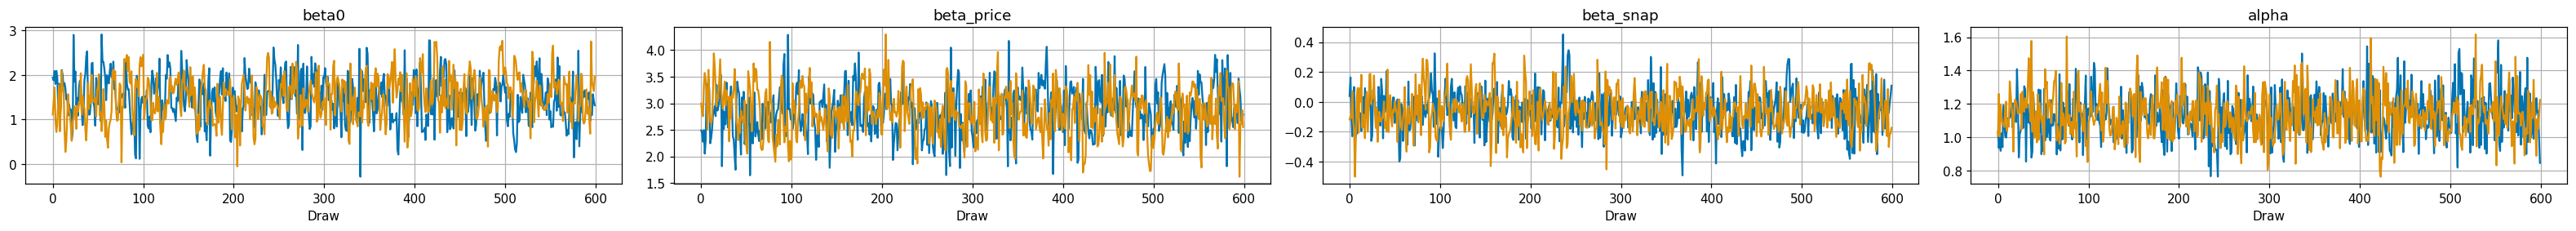

In [6]:
_ = az.plot_trace(
    uni_idata,
    var_names=["beta0", "beta_price", "beta_snap", "alpha"],
    backend="matplotlib",
)
plt.tight_layout()

## 4 · Hold-out forecast + 90% credible band

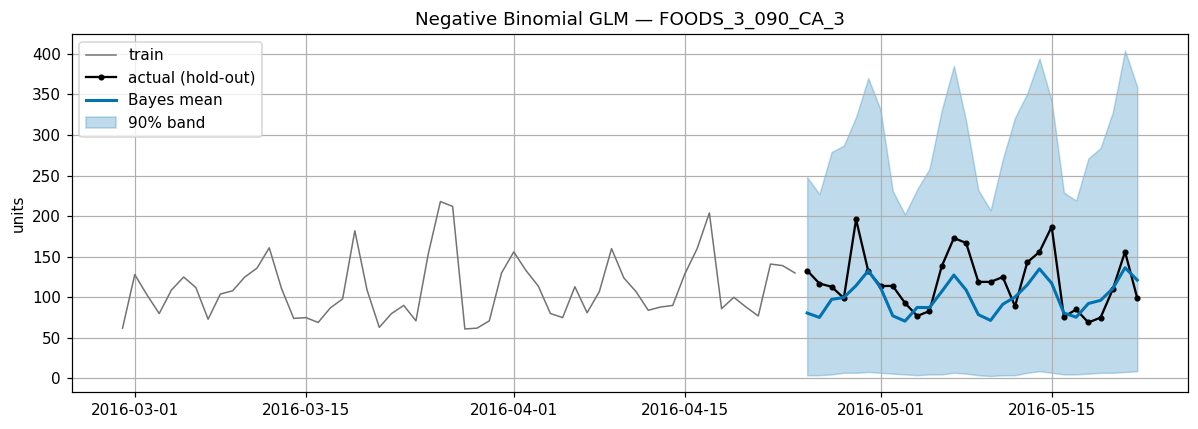

In [7]:
post = extract_posterior(uni_idata)
y_ppc = negbin_predictive_draws(post, test)

y_mean = y_ppc.mean(axis=0)
y_lo, y_hi = np.quantile(y_ppc, [0.05, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(11, 4))
history = train.tail(56)
ax.plot(history["ds"], history["y"], label="train", color="0.45", lw=1)
ax.plot(test["ds"], test["y"], label="actual (hold-out)", color="black", marker="o", ms=3)
ax.plot(test["ds"], y_mean, label="Bayes mean", color="C0", lw=2)
ax.fill_between(test["ds"], y_lo, y_hi, color="C0", alpha=0.25, label="90% band")
ax.set_title(f"Negative Binomial GLM — {hero_id}")
ax.set_ylabel("units")
ax.legend(loc="upper left")
plt.tight_layout()

## 5 · Benchmark vs SeasonalNaive (same hold-out)

In [8]:
sf_train = train[["unique_id", "ds", "y"]]
sf = StatsForecast(models=[SeasonalNaive(season_length=7)], n_jobs=1, freq="D")
sf.fit(sf_train)
sf_fcst = sf.predict(h=HORIZON).reset_index()
naive_col = "SeasonalNaive"

comp = test[["ds", "y"]].merge(sf_fcst[["ds", naive_col]], on="ds", how="left")

metrics = pd.DataFrame(
    {
        "model": ["Bayes-NegBin", "SeasonalNaive"],
        "MAE": [
            np.abs(y_mean - test["y"].to_numpy()).mean(),
            np.abs(comp[naive_col] - comp["y"]).mean(),
        ],
    }
)
metrics

,model,MAE
0,Bayes-NegBin,26.989792
1,SeasonalNaive,22.035715


## 6 · Partial pooling across a department slice

The full M5 panel has **30,490** bottom series. Fitting independent MCMC to each
is infeasible; the Bayesian move is **hierarchical shrinkage**:

$$
\beta_{0,i} \sim \mathcal{N}(\mu_{\beta_0},\ \sigma_{\beta_0}), \quad i = 1\ldots I
$$

Series in the same department share $\mu_{\beta_0}$ but keep their own intercepts.
Cold-start / sparse SKUs borrow strength from siblings instead of over-fitting noise.

Below we fit **five FOODS series in CA_1** with a shared day-of-week vector and
series-specific intercepts + dispersion.

In [9]:
dept_slice = (
    long.loc[(long["dept_id"] == hero["dept_id"].iloc[0]) & (long["store_id"] == hero["store_id"].iloc[0])]
    .sort_values(["unique_id", "ds"])
    .groupby("unique_id", observed=True)
    .tail(LAST_N_DAYS)
    .pipe(add_minimal_features)
)

top_ids = dept_slice.groupby("unique_id", observed=True)["y"].sum().nlargest(N_HIER_SERIES).index
panel = dept_slice.loc[dept_slice["unique_id"].isin(top_ids)].copy()

id_map = {uid: i for i, uid in enumerate(top_ids)}
panel["series_idx"] = panel["unique_id"].map(id_map).astype(int)
n_series = len(id_map)

print(f"partial pooling panel: {n_series} series × {panel.groupby('unique_id').size().iloc[0]} days")
panel[["unique_id", "series_idx"]].drop_duplicates()

partial pooling panel: 5 series × 0 days


/tmp/ipykernel_934516/1210459953.py:16: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(f"partial pooling panel: {n_series} series × {panel.groupby('unique_id').size().iloc[0]} days")


,unique_id,series_idx
10483379,FOODS_3_090_CA_3,0
10967957,FOODS_3_120_CA_3,2
13013924,FOODS_3_252_CA_3,3
13447731,FOODS_3_282_CA_3,4
18133677,FOODS_3_586_CA_3,1


In [10]:
coords_h = {"dayofweek": np.arange(7), "series": np.arange(n_series)}

with pm.Model(coords=coords_h) as hier_model:
    series_idx = pm.Data("series_idx", panel["series_idx"].to_numpy())
    dow = pm.Data("dow", panel["dayofweek"].to_numpy())
    price = pm.Data("price", panel["price_norm"].to_numpy())
    snap = pm.Data("snap", panel["snap"].to_numpy())

    mu_beta0 = pm.Normal("mu_beta0", 0, 1)
    sigma_beta0 = pm.HalfNormal("sigma_beta0", 0.5)
    beta0 = pm.Normal("beta0", mu_beta0, sigma_beta0, dims="series")

    mu_log_alpha = pm.Normal("mu_log_alpha", 0, 0.5)
    sigma_log_alpha = pm.HalfNormal("sigma_log_alpha", 0.5)
    log_alpha = pm.Normal("log_alpha", mu_log_alpha, sigma_log_alpha, dims="series")
    alpha = pm.Deterministic("alpha", pm.math.exp(log_alpha), dims="series")

    beta_dow = pm.Normal("beta_dow", 0, 0.5, dims="dayofweek")
    beta_price = pm.Normal("beta_price", 0, 0.5)
    beta_snap = pm.Normal("beta_snap", 0, 0.5)

    log_mu = beta0[series_idx] + beta_dow[dow] + beta_price * price + beta_snap * snap
    mu = pm.Deterministic("mu", pm.math.exp(log_mu))
    pm.NegativeBinomial("y", mu=mu, alpha=alpha[series_idx], observed=panel["y"].to_numpy())

    hier_idata = pm.sample(
        draws=400,
        tune=400,
        chains=2,
        target_accept=0.92,
        random_seed=SETTINGS.seed,
        progressbar=True,
    )

az.summary(hier_idata, var_names=["mu_beta0", "sigma_beta0", "mu_log_alpha", "sigma_log_alpha", "beta_price"])

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [mu_beta0, sigma_beta0, beta0, mu_log_alpha, sigma_log_alpha, log_alpha, beta_dow, beta_price, beta_snap]


Output()

Sampling 2 chains for 400 tune and 400 draw iterations (800 + 800 draws total) took 23 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


,mean,sd,eti89_lb,eti89_ub,ess_bulk,ess_tail,r_hat,mcse_mean,mcse_sd
mu_beta0,0.26,0.53,-0.59,1.1,209,293,1.00,0.037,0.024
sigma_beta0,0.38,0.15,0.2,0.66,703,501,1.02,0.0072,0.0087
mu_log_alpha,0.72,0.38,0.085,1.3,805,438,1.00,0.014,0.0094
sigma_log_alpha,1.17,0.24,0.82,1.6,860,573,1.00,0.0088,0.007
beta_price,3.67,0.5,2.9,4.4,234,283,1.01,0.033,0.022


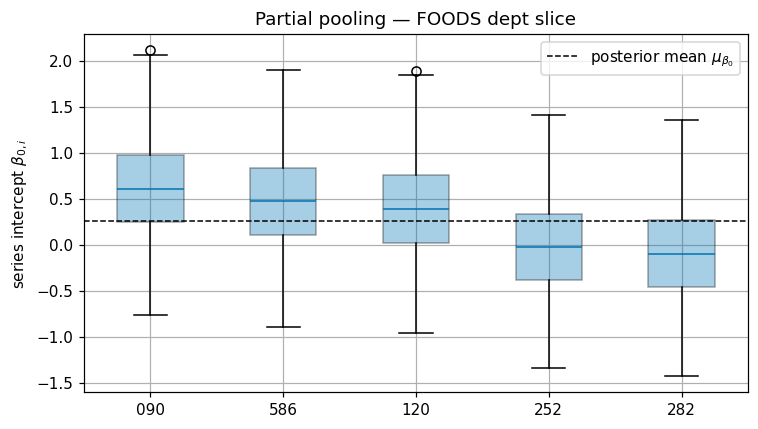

In [11]:
# Shrinkage plot: series intercepts vs department mean
hier_post = extract_posterior(hier_idata, var_names=["beta0", "mu_beta0", "sigma_beta0"])
beta0_draws = hier_post["beta0"]  # (draws, series)
mu_draws = hier_post["mu_beta0"]

fig, ax = plt.subplots(figsize=(7, 4))
for j, uid in enumerate(top_ids):
    ax.boxplot(
        beta0_draws[:, j],
        positions=[j],
        widths=0.5,
        patch_artist=True,
        boxprops={"facecolor": "C0", "alpha": 0.35},
        medianprops={"color": "C0"},
    )
ax.axhline(mu_draws.mean(), color="black", ls="--", lw=1, label=r"posterior mean $\mu_{\beta_0}$")
ax.set_xticks(range(n_series), [uid.split("_")[2] for uid in top_ids], rotation=0)
ax.set_ylabel(r"series intercept $\beta_{0,i}$")
ax.set_title("Partial pooling — FOODS dept slice")
ax.legend()
plt.tight_layout()

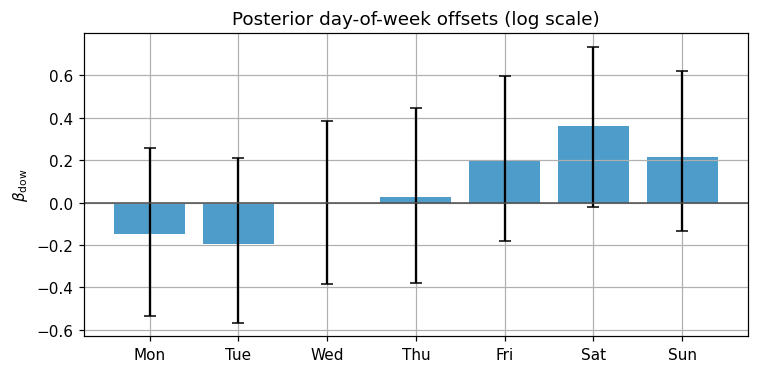

In [12]:
# Posterior day-of-week effects (univariate hero model)
dow_post = extract_posterior(uni_idata, var_names=["beta_dow"])["beta_dow"]
dow_mean = dow_post.mean(axis=0)
dow_lo, dow_hi = np.quantile(dow_post, [0.05, 0.95], axis=0)

fig, ax = plt.subplots(figsize=(7, 3.5))
labels = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
ax.bar(labels, dow_mean, yerr=[dow_mean - dow_lo, dow_hi - dow_mean], capsize=4, color="C0", alpha=0.7)
ax.axhline(0, color="0.3", lw=1)
ax.set_title("Posterior day-of-week offsets (log scale)")
ax.set_ylabel(r"$\beta_{\mathrm{dow}}$")
plt.tight_layout()

## 7 · Scaling to full M5 (research roadmap)

This notebook stays deliberately small. A production-grade Bayesian M5 stack would
layer the following ideas — many mirror what the repo already does with frequentist
tools:

| Layer | Frequentist analogue in this repo | Bayesian upgrade |
|---|---|---|
| Likelihood | Tweedie LightGBM | Hierarchical NegBin / ZIP for zero inflation |
| Global pooling | One LGBM across all series | Multi-level regression with partial pooling on `dept_id`, `store_id` |
| Time dynamics | Lags / rolling means in `models/lgbm.py` | Latent local level + seasonality (DLM / BSTS) |
| Hierarchy | `hier_cv` reconciliation | Joint model or coherent posterior on aggregated levels |
| Uncertainty | `notebooks/conformal/` split intervals | Native posterior predictive (+ optional conformal calibration) |
| Compute | Vectorised LGBM | **Amortised inference** — variational Bayes, INLA, or fit on embeddings then fine-tune |

**Practical path I would take:**

1. **Stage A — panel GLM:** variational NegBin with random intercepts per series (PyMC/NumPyro ADVI) on 500–2k series; score with `wrmsse_for_models`.
2. **Stage B — state-space:** replace weekly dummies with stochastic seasonality for series with long history.
3. **Stage C — reconcile:** post-process posterior means through the same `S` matrix as `hierarchicalforecast`, or embed aggregation constraints in the generative model.

Until Stage A beats capped `cv-lgbm`, keep LightGBM as the production point forecast and use Bayes for **risk / inventory** use-cases where calibrated intervals matter.